# Task 1: Exploratory Data Analysis (EDA)

This notebook covers the initial exploratory data analysis for the financial news dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set(style="whitegrid")

In [2]:
# Load news data
news_path = '../data/raw/news_data/raw_analyst_ratings.csv'
df = pd.read_csv(news_path)
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


## 1. Descriptive Statistics

### Headline Lengths

In [3]:
df['headline_length'] = df['headline'].apply(len)
df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

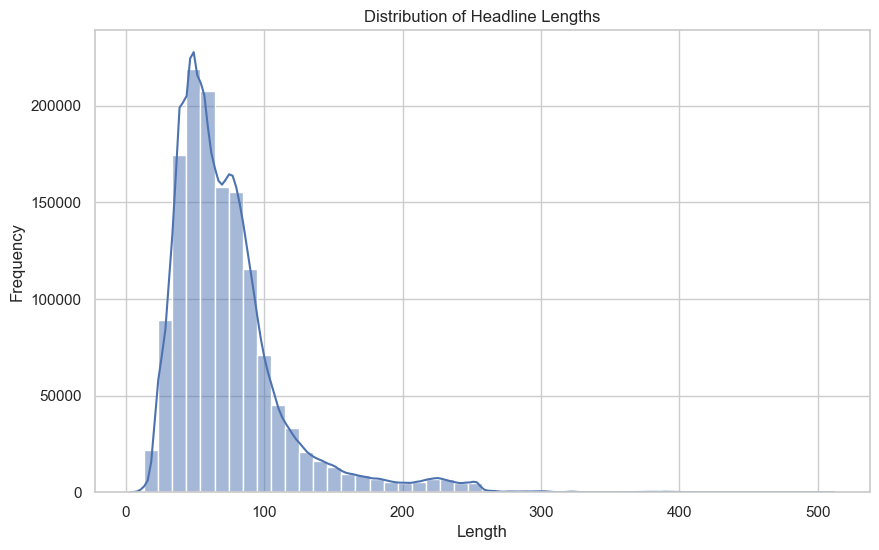

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_length'], bins=50, kde=True)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

### Publisher Analysis

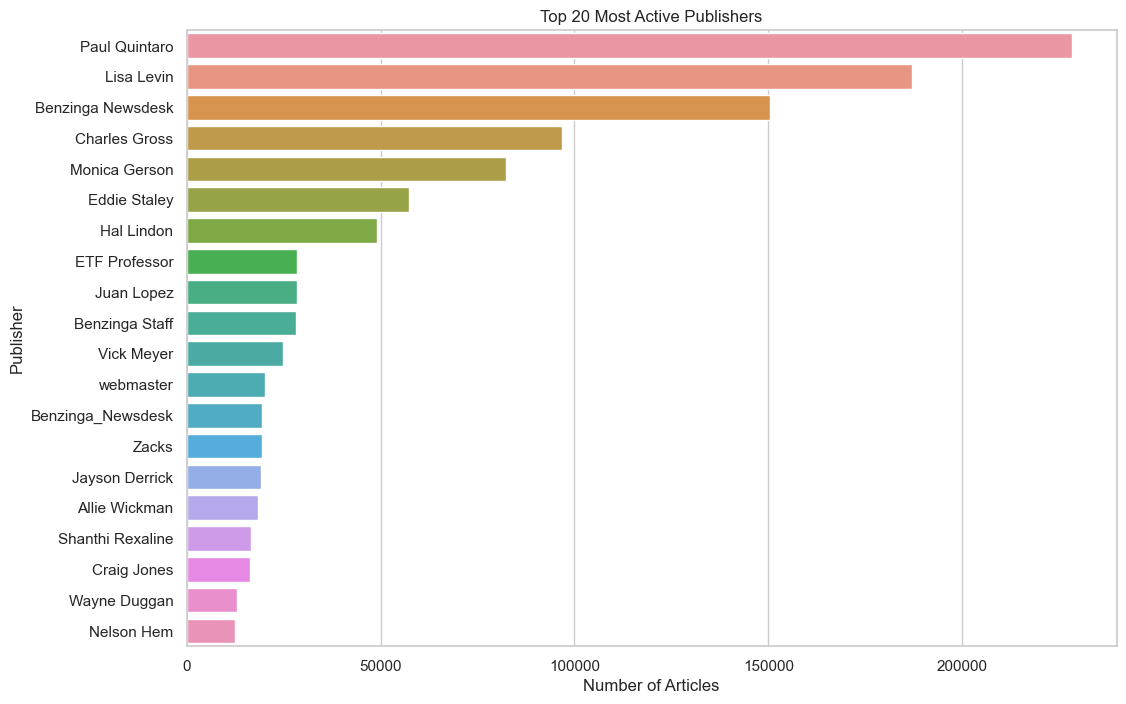

In [5]:
publisher_counts = df['publisher'].value_counts()
top_publishers = publisher_counts.head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_publishers.values, y=top_publishers.index)
plt.title('Top 20 Most Active Publishers')
plt.xlabel('Number of Articles')
plt.ylabel('Publisher')
plt.show()

### Publication Trends Over Time

In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()
df['hour'] = df['date'].dt.hour
df['date_only'] = df['date'].dt.date

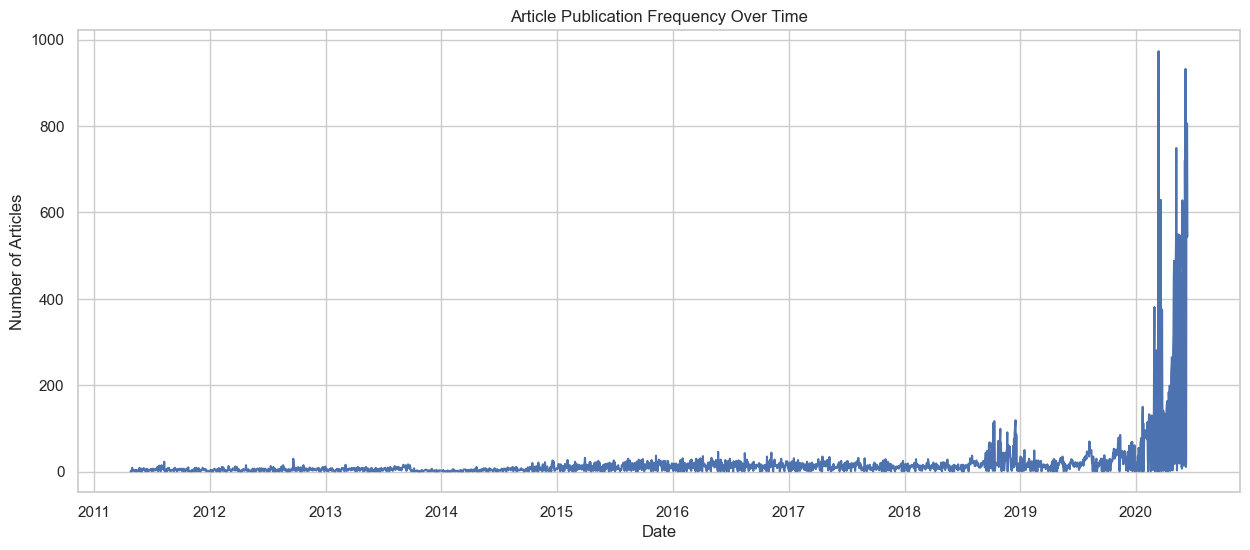

In [7]:
daily_counts = df.groupby('date_only').size()

plt.figure(figsize=(15, 6))
daily_counts.plot()
plt.title('Article Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.show()